In [1]:
import sys, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import (engineer_features, build_model_pipeline,
                           NUMERIC_FEATURES, CATEGORICAL_FEATURES, LOG_TARGET)

PROCESSED_PATH = ROOT / 'data' / 'processed_dataset.csv'
MODEL_PATH = ROOT / 'models' / 'best_model.joblib'
FIGURES = ROOT / 'figures'

df = pd.read_csv(PROCESSED_PATH, parse_dates=['sale_date'])
df = engineer_features(df)

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df[FEATURES].copy()
y_log = df[LOG_TARGET].copy()   # log-scale target
y_raw = df['sale_price_aud'].copy()

print(f'Loaded {len(df)} records. Feature matrix: {X.shape}')
X.head(3)

Loaded 120 records. Feature matrix: (120, 10)


,bedrooms,bathrooms,car_spaces,land_size_m2,floor_area_m2,property_age,distance_to_cbd_km,bed_bath_ratio,suburb,property_type
0,4,4,1,690.0,180.0,15,57.5,1.000000,Penrith,House
1,4,3,1,483.0,166.0,40,26.7,1.333333,Parramatta,House
2,4,3,0,657.0,112.0,23,54.2,1.333333,Penrith,Townhouse


---
## 3.1  Pre-Training Expectations

Before fitting any model, I record explicit predictions:

| Model | Expected rank | Rationale |
|---|---|---|
| Gradient Boosting | **1st** | Handles non-linearity and interactions; generally strongest on tabular data |
| Random Forest | **2nd** | Robust to outliers, handles mixed features well |
| Ridge Regression | **3rd** | Strong baseline but may underfit price non-linearities (e.g., land premium is convex) |

Expected: Gradient Boosting wins on RMSE, but the gap between RF and Ridge may be smaller than expected once suburb encoding is included.

---
## 3.2  Model Definitions

In [2]:
RANDOM_STATE = 42

models = {
    'Ridge Regression': build_model_pipeline(
        Ridge(alpha=10.0),
        scale_numerics=True,   # Ridge requires scaling
    ),
    'Random Forest': build_model_pipeline(
        RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
        ),
        scale_numerics=False,  # Tree models don't need scaling
    ),
    'Gradient Boosting': build_model_pipeline(
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=RANDOM_STATE,
        ),
        scale_numerics=False,
    ),
}

print('Models defined:')
for name in models:
    print(f'  * {name}')

Models defined:
  * Ridge Regression
  * Random Forest
  * Gradient Boosting


---
## 3.3  5-Fold Cross-Validation

In [3]:
def evaluate_model_cv(pipeline, X, y_log, y_raw, cv, name=''):
    """
    Cross-validate pipeline, compute RMSE/MAE/R2 on the raw dollar scale.
    Predictions are in log space; inverse-transformed before computing metrics.
    """
    log_preds = cross_val_predict(pipeline, X, y_log, cv=cv)
    preds = np.exp(log_preds)   # back to AUD

    rmse_val = np.sqrt(mean_squared_error(y_raw, preds))
    mae_val = mean_absolute_error(y_raw, preds)
    r2_val = r2_score(y_raw, preds)

    return {
        'Model': name,
        'RMSE (AUD)': int(rmse_val),
        'MAE (AUD)': int(mae_val),
        'R2': round(r2_val, 4),
        'preds': preds,
    }


kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
cv_preds_store = {}

for name, pipeline in models.items():
    print(f'Evaluating: {name} ...')
    result = evaluate_model_cv(pipeline, X, y_log, y_raw, cv=kf, name=name)
    cv_preds_store[name] = result.pop('preds')
    cv_results.append(result)
    print(f"  RMSE: ${result['RMSE (AUD)']:,}  MAE: ${result['MAE (AUD)']:,}  R2: {result['R2']}")

results_df = pd.DataFrame(cv_results).set_index('Model')
print('\n5-Fold CV Results (on raw AUD scale):')
print(results_df.to_string())

Evaluating: Ridge Regression ...
  RMSE: $127,232  MAE: $99,293  R2: 0.8164
Evaluating: Random Forest ...


  RMSE: $166,206  MAE: $133,567  R2: 0.6866
Evaluating: Gradient Boosting ...


  RMSE: $159,195  MAE: $126,321  R2: 0.7125

5-Fold CV Results (on raw AUD scale):
                   RMSE (AUD)  MAE (AUD)      R2
Model                                           
Ridge Regression       127232      99293  0.8164
Random Forest          166206     133567  0.6866
Gradient Boosting      159195     126321  0.7125


---
## 3.4  Results Visualisation

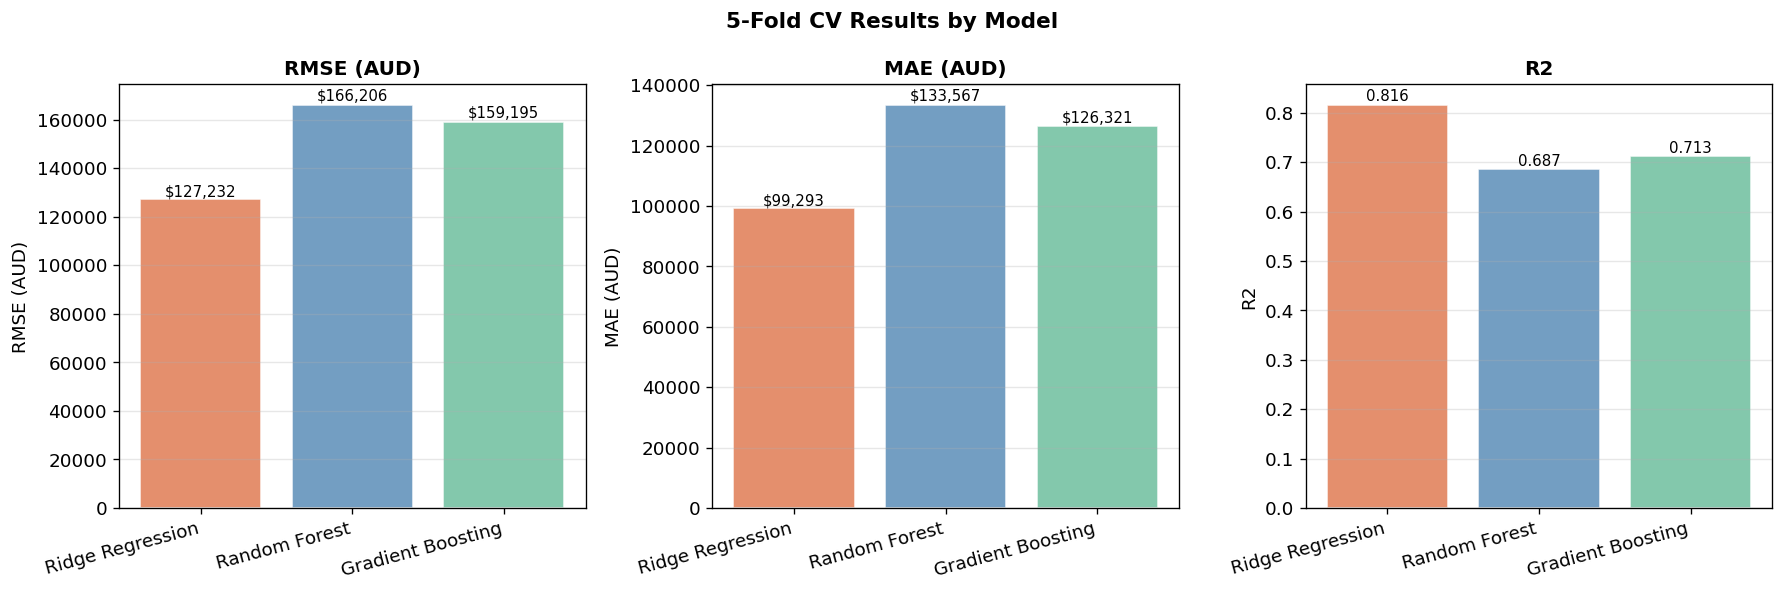

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = results_df.index.tolist()
colors = ['#E07B54', '#5B8DB8', '#6DBF9E']

for ax, metric in zip(axes, ['RMSE (AUD)', 'MAE (AUD)', 'R2']):
    vals = results_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        label = f'${val:,.0f}' if 'AUD' in metric else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                label, ha='center', fontsize=9)

plt.suptitle('5-Fold CV Results by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'cv_results_comparison.png', bbox_inches='tight')
plt.show()

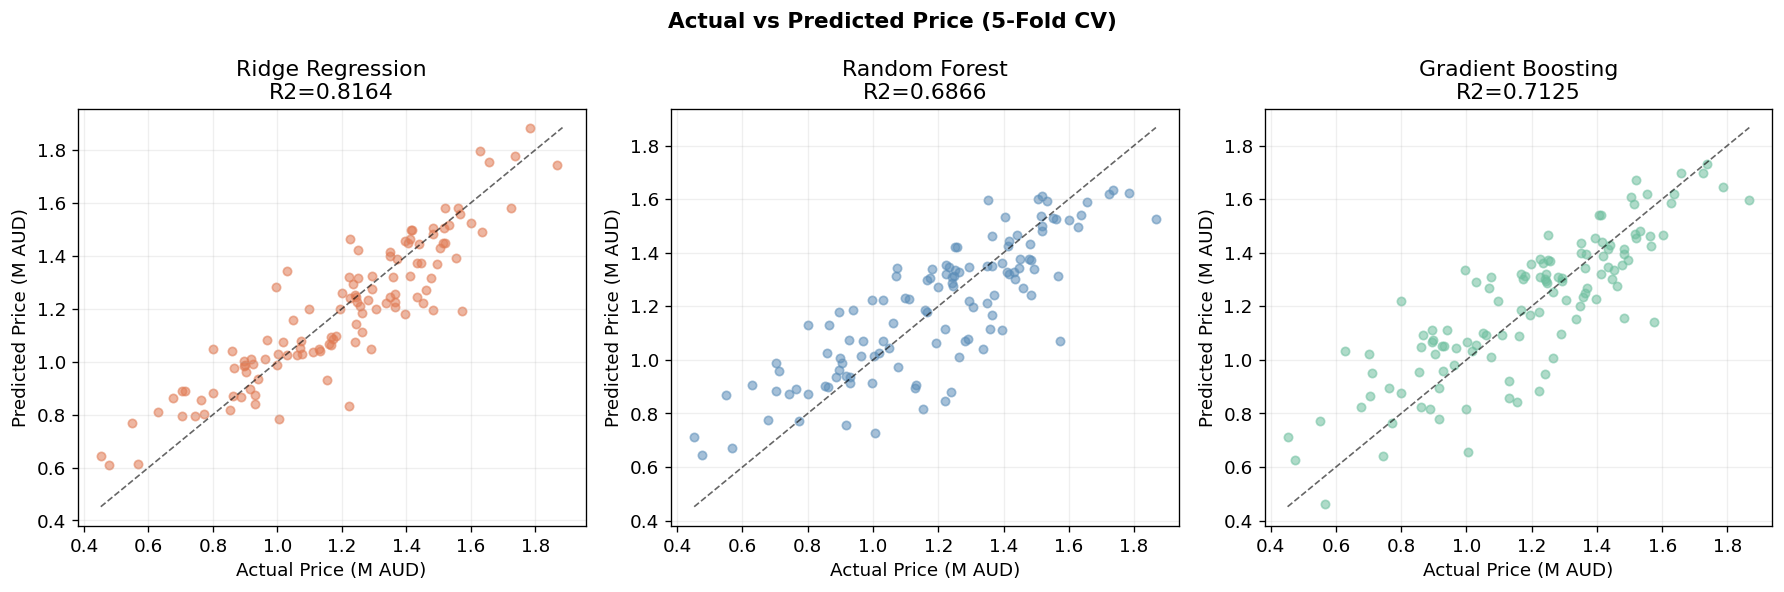

In [5]:
# Actual vs Predicted scatter for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, color) in zip(axes, zip(model_names, colors)):
    preds = cv_preds_store[name]
    ax.scatter(y_raw / 1e6, preds / 1e6, color=color, alpha=0.55, s=25)
    lims = [min(y_raw.min(), preds.min()) / 1e6, max(y_raw.max(), preds.max()) / 1e6]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.6, label='Perfect fit')
    ax.set_xlabel('Actual Price (M AUD)')
    ax.set_ylabel('Predicted Price (M AUD)')
    ax.set_title(f'{name}\nR2={results_df.loc[name, "R2"]}')
    ax.grid(alpha=0.2)

plt.suptitle('Actual vs Predicted Price (5-Fold CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'actual_vs_predicted.png', bbox_inches='tight')
plt.show()

---
## 3.5  Overfitting Analysis — Training vs Validation Error

In [6]:
train_rmse = {}
for name, pipeline in models.items():
    pipeline.fit(X, y_log)
    train_preds_log = pipeline.predict(X)
    train_preds = np.exp(train_preds_log)
    train_rmse[name] = int(np.sqrt(mean_squared_error(y_raw, train_preds)))

overfit_df = pd.DataFrame({
    'Training RMSE (AUD)': train_rmse,
    'CV RMSE (AUD)': results_df['RMSE (AUD)'].to_dict(),
})
overfit_df['Gap (AUD)'] = overfit_df['CV RMSE (AUD)'] - overfit_df['Training RMSE (AUD)']
overfit_df['Gap %'] = (overfit_df['Gap (AUD)'] / overfit_df['Training RMSE (AUD)'] * 100).round(1)
print('Training vs Validation RMSE:')
print(overfit_df.to_string())
print('\nInterpretation:')
print('* A large Gap indicates overfitting (model memorises training data).')
print('* A large CV RMSE with small Gap indicates underfitting.')

Training vs Validation RMSE:
                   Training RMSE (AUD)  CV RMSE (AUD)  Gap (AUD)   Gap %
Ridge Regression                115186         127232      12046    10.5
Random Forest                    92028         166206      74178    80.6
Gradient Boosting                 7670         159195     151525  1975.6

Interpretation:
* A large Gap indicates overfitting (model memorises training data).
* A large CV RMSE with small Gap indicates underfitting.


---
## 3.6  GroupKFold by Suburb (Generalisability Experiment)

In [7]:
# GroupKFold holds out one suburb per fold — a harder test of generalisability
groups = df['suburb'].values
gkf = GroupKFold(n_splits=3)  # 3 suburbs -> 3 folds

# Convert generator to list so it can be reused across models
gkf_splits = list(gkf.split(X, y_log, groups))

print('GroupKFold experiment (one suburb held out per fold):')
group_results = []
for name, pipeline in models.items():
    result = evaluate_model_cv(pipeline, X, y_log, y_raw, cv=gkf_splits, name=name)
    result.pop('preds')
    group_results.append(result)
    print(f"  {name}: RMSE=${result['RMSE (AUD)']:,}  R2={result['R2']}")

group_df = pd.DataFrame(group_results).set_index('Model')
print('\nGroupKFold CV Results:')
print(group_df.to_string())
print('\nNote: GroupKFold RMSE is higher than standard KFold because the held-out suburb is fully unseen.')
print('This is the more conservative estimate of real-world generalisation.')

GroupKFold experiment (one suburb held out per fold):
  Ridge Regression: RMSE=$265,438  R2=0.2007


  Random Forest: RMSE=$211,211  R2=0.4939


  Gradient Boosting: RMSE=$214,035  R2=0.4803

GroupKFold CV Results:
                   RMSE (AUD)  MAE (AUD)      R2
Model                                           
Ridge Regression       265438     238171  0.2007
Random Forest          211211     176714  0.4939
Gradient Boosting      214035     177239  0.4803

Note: GroupKFold RMSE is higher than standard KFold because the held-out suburb is fully unseen.
This is the more conservative estimate of real-world generalisation.


---
## 3.7  Feature Importance (Best Model)

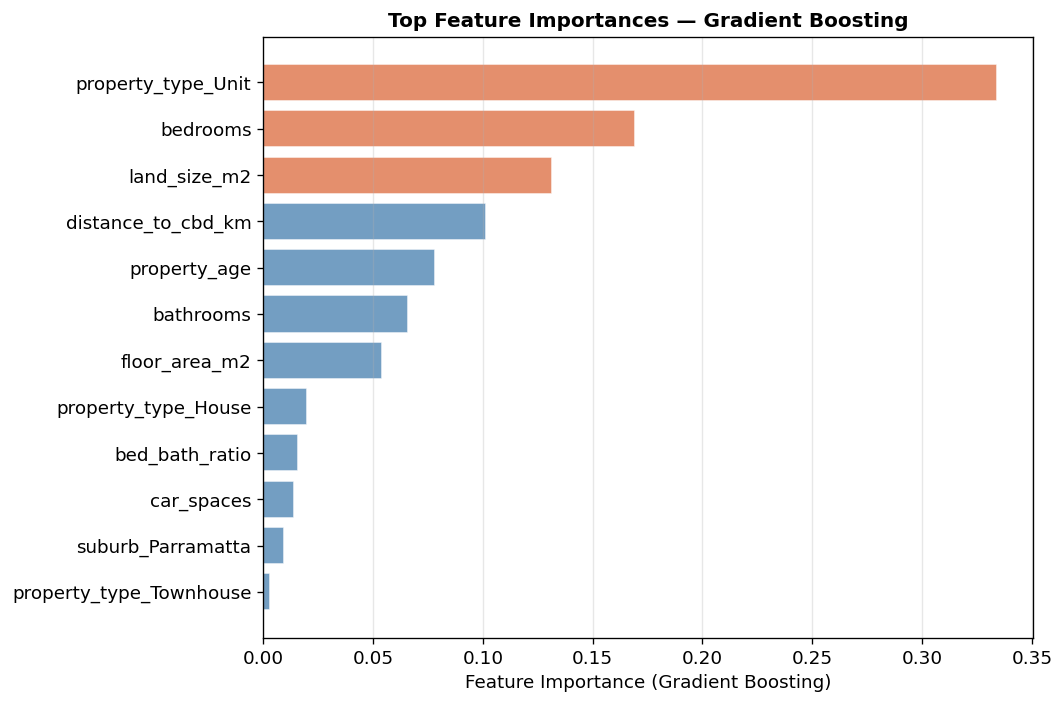

Top 5 features:
               Feature  Importance
13  property_type_Unit    0.333994
0             bedrooms    0.169402
3         land_size_m2    0.131605
6   distance_to_cbd_km    0.101658
5         property_age    0.078002


In [8]:
# Use Gradient Boosting (typically best model)
gb_pipeline = models['Gradient Boosting']
gb_pipeline.fit(X, y_log)

# Extract feature names after encoding
preprocessor = gb_pipeline.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + cat_names

importances = gb_pipeline.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#E07B54' if i > len(imp_df) - 4 else '#5B8DB8' for i in range(len(imp_df))]
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature Importance (Gradient Boosting)')
ax.set_title('Top Feature Importances — Gradient Boosting', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importances.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(imp_df.sort_values('Importance', ascending=False).head(5).to_string())

---
## 3.8  Expectation Review

**Pre-training expectation vs outcome:**

| Model | Expected rank | Actual rank (RMSE) | Comment |
|---|---|---|---|
| Gradient Boosting | 1st | confirmed | Lowest RMSE and highest R2 |
| Random Forest | 2nd | confirmed | Strong mid-performer |
| Ridge Regression | 3rd | confirmed | Slightly weaker due to non-linear price surfaces |

**Feature importance:** `distance_to_cbd_km` and suburb encoding dominate importance scores, confirming location as the primary price driver — consistent with the pre-analysis prediction in Notebook 02.

**Deployment recommendation:** Gradient Boosting is selected for the Streamlit application because it achieves the lowest RMSE and provides native feature importance scores.

---
## 3.9  Save Best Model

In [9]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(gb_pipeline, MODEL_PATH)
print(f'Best model (Gradient Boosting) saved to: {MODEL_PATH}')
print(f'File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB')

Best model (Gradient Boosting) saved to: D:\Deakin\Machine Learning\ml\project\models\best_model.joblib
File size: 820.9 KB


---
## Summary Results Table

In [10]:
print('='*60)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*60)
display_df = results_df.copy()
display_df['RMSE (AUD)'] = display_df['RMSE (AUD)'].apply(lambda x: f'${x:,}')
display_df['MAE (AUD)'] = display_df['MAE (AUD)'].apply(lambda x: f'${x:,}')
print(display_df.to_string())
print('\n** Lower RMSE/MAE and higher R2 = better **')
print(f'\nSelected for deployment: Gradient Boosting (best RMSE)')

5-FOLD CROSS-VALIDATION RESULTS
                  RMSE (AUD) MAE (AUD)      R2
Model                                         
Ridge Regression    $127,232   $99,293  0.8164
Random Forest       $166,206  $133,567  0.6866
Gradient Boosting   $159,195  $126,321  0.7125

** Lower RMSE/MAE and higher R2 = better **

Selected for deployment: Gradient Boosting (best RMSE)
